# Chapter 6: Integration

**Source Span.** *An Introduction to Manifolds*, printed pages 236-273, PDF pages 255-292. This corrects the stale scaffold span that previously pointed into later material.

**Chapter goal.** Learn how orientation turns top-degree forms into signed integrals, how the same sign convention controls boundaries, and how Stokes's theorem packages line integrals and Green's theorem into one boundary rule.

The notebook uses the source pages for structure and terminology only. All prose, examples, diagrams, code, and checks below are original teaching material. The central computational translation is: an orientation is a sign of a determinant or top covector, a boundary orientation is an outward-vector-first determinant test, and an integral of a form is a signed Jacobian-weighted integral that changes sign when orientation reverses.

## Visual Storyboard

**Chapter goal:** connect four signs that often get learned separately: frame orientation, chart-transition orientation, boundary orientation, and the sign of an integral.

**Source Span read:** printed pages 236-273, PDF pages 255-292. The span contains Sections 21-23: orientations, manifolds with boundary, and integration on manifolds through Stokes's theorem.

**concept inventory:** ordered bases and determinant sign; nonzero top covectors and orientation forms; continuous pointwise orientations; oriented atlases; the Mobius-band obstruction; orientability examples from regular zero sets, Lie groups, tangent bundles, and projective spaces; manifolds with boundary modeled on `H^n`; smooth invariance of domain as the reason boundary and interior are chart-independent; tangent vectors and forms at boundary points; outward-pointing vector fields; boundary orientation; Riemann integration and measure-zero boundaries; integration of `n`-forms on `R^n`; compact support and partitions of unity on manifolds; parametrized sets; Stokes's theorem; line integrals; Green's theorem; the sphere area form.

**Library Routing table:**

| concept | representation | library | why this library | fallback |
| --- | --- | --- | --- | --- |
| orientation classes | frame and parallelogram determinants | SymPy + Matplotlib | exact determinant sign plus a readable 2D frame diagram | NumPy-only determinant check |
| oriented-atlas obstruction | signed transition-cycle diagram | NetworkX + Matplotlib | a sign product around a cycle is the inspectable obstruction | plain table of transition signs |
| boundary orientation | half-plane with outward normal and induced tangent | SymPy + Matplotlib | determinant and contraction signs can be shown side by side | text-only sign convention |
| domains of integration | Darboux grid around a disk | NumPy + Matplotlib | upper-lower sums make the measure-zero boundary idea visible | symbolic rectangle example |
| parametrized integration | ellipse parameter map and reversal | SymPy + Plotly | signed Jacobian and orientation reversal are easier to compare interactively | static Matplotlib grid |
| Stokes specializations | Green and line-integral numeric checks | NumPy + Matplotlib | boundary and interior integrals can be sampled and compared directly | exact SymPy integral only |
| sphere area form | spherical parameterization and density | SymPy + Plotly | 3D surface plus exact pullback verifies the area form | static sphere projection |

**visual sequence:**

1. `ch06-visual-storyboard.png`: dependency map from orientation data to Stokes checks. Validation: graph reaches every check from orientation data.
2. `orientation-frame-sign.png`: two frames with opposite determinant sign. Validation: top covector evaluation equals determinant sign.
3. `mobius-orientation-obstruction.png`: endpoint gluing on the open Mobius band. Validation: gluing derivative has determinant `-1` and the sign product around the loop is negative.
4. `boundary-outward-first.png`: `H^2` boundary convention. Validation: `(outward, boundary tangent)` is positively oriented and contraction gives `dx`.
5. `riemann-disk-boundary-grid.png`: upper and lower sums for a disk indicator. Validation: the upper-lower gap decreases under refinement.
6. `parameterized-ellipse-orientation.html`: orientation-preserving and reversing parameterizations of the same ellipse. Validation: signed integrals are `+piab` and `-piab`.
7. `stokes-green-line-checks.png`: numerical Green and line-integral checks. Validation: residuals are below tolerance.
8. `sphere-area-form.html`: sphere area density under spherical coordinates. Validation: the pullback is `sin(phi) dphi wedge dtheta` and integrates to `4*pi`.

**artifact plan:** write PNG/SVG-like static figures to `artifacts/chapter-06-integration/figures/`, interactive Plotly HTML to `artifacts/chapter-06-integration/html/`, invariant summaries to `artifacts/chapter-06-integration/checks/`, and routing/refinement tables to `artifacts/chapter-06-integration/tables/`.

**computational checks:** determinant signs, Mobius cycle sign, outward-first determinant, contraction coefficient, Darboux gap monotonicity, signed Jacobians, Green residual, line-integral residual, sphere pullback identity, artifact existence, and nonzero artifact sizes.

**proof-visualization strategy:** use a dependency graph for the proof architecture, a sign cycle for nonorientability, determinant/contraction identities for boundary orientation, and numeric residuals for the Stokes specializations.

**implementation notes:** all paths are book-local, all artifacts are generated by visible notebook cells, and the final cell named `final_sanity` asserts the core identities and artifact contract.

In [1]:
from pathlib import Path
import json
import math
import os
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
from IPython.display import Markdown, display


def find_book_root() -> Path:
    starts = [Path.cwd(), Path.cwd() / "An-Introduction-to-Manifolds", Path.cwd().parent]
    seen = set()
    for start in starts:
        try:
            start = start.resolve()
        except OSError:
            continue
        if start in seen:
            continue
        seen.add(start)
        for candidate in [start, *start.parents]:
            if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("Could not locate An-Introduction-to-Manifolds course root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-06-integration"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

generated_artifacts = []

def keep(path):
    path = Path(path)
    generated_artifacts.append(path)
    return path


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def save_plotly_standalone(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_html(str(path), include_plotlyjs=True, full_html=True)
    return path


def show(path, **kwargs):
    display_path = Path(os.path.relpath(Path(path).resolve(), Path.cwd().resolve()))
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Consider using IPython.display.IFrame instead")
        display_artifact(display_path, **kwargs)


print("Book root located")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")

Book root located
Artifact root: artifacts/chapter-06-integration


## Translation Guide

The chapter has one persistent theme: signs are geometry, not bookkeeping. A chart transition with positive Jacobian preserves an orientation; a negative one reverses it. A top-degree covector evaluates an ordered frame and returns exactly the determinant sign that chooses an orientation class. A boundary inherits the sign that makes an outward normal followed by a boundary frame agree with the ambient orientation. Finally, an integral of a top form records this sign because pullback multiplies the coefficient by the signed Jacobian, not by its absolute value.

The source also separates two kinds of boundary language. The topological boundary of a subset depends on an ambient space. The manifold boundary is intrinsic and is detected in charts modeled on the half-space `H^n`. Smooth invariance of domain is the tool that prevents a diffeomorphism of half-space charts from mixing boundary points with interior points.

For computation, we will use small finite models:

- frames are columns of a matrix;
- top covectors are determinant functions;
- atlas transitions carry signs on overlaps;
- boundary orientation is a contraction test;
- an `n`-form integral is a coefficient integral after pullback;
- Stokes's theorem is checked by comparing an exterior-derivative integral with a boundary integral.

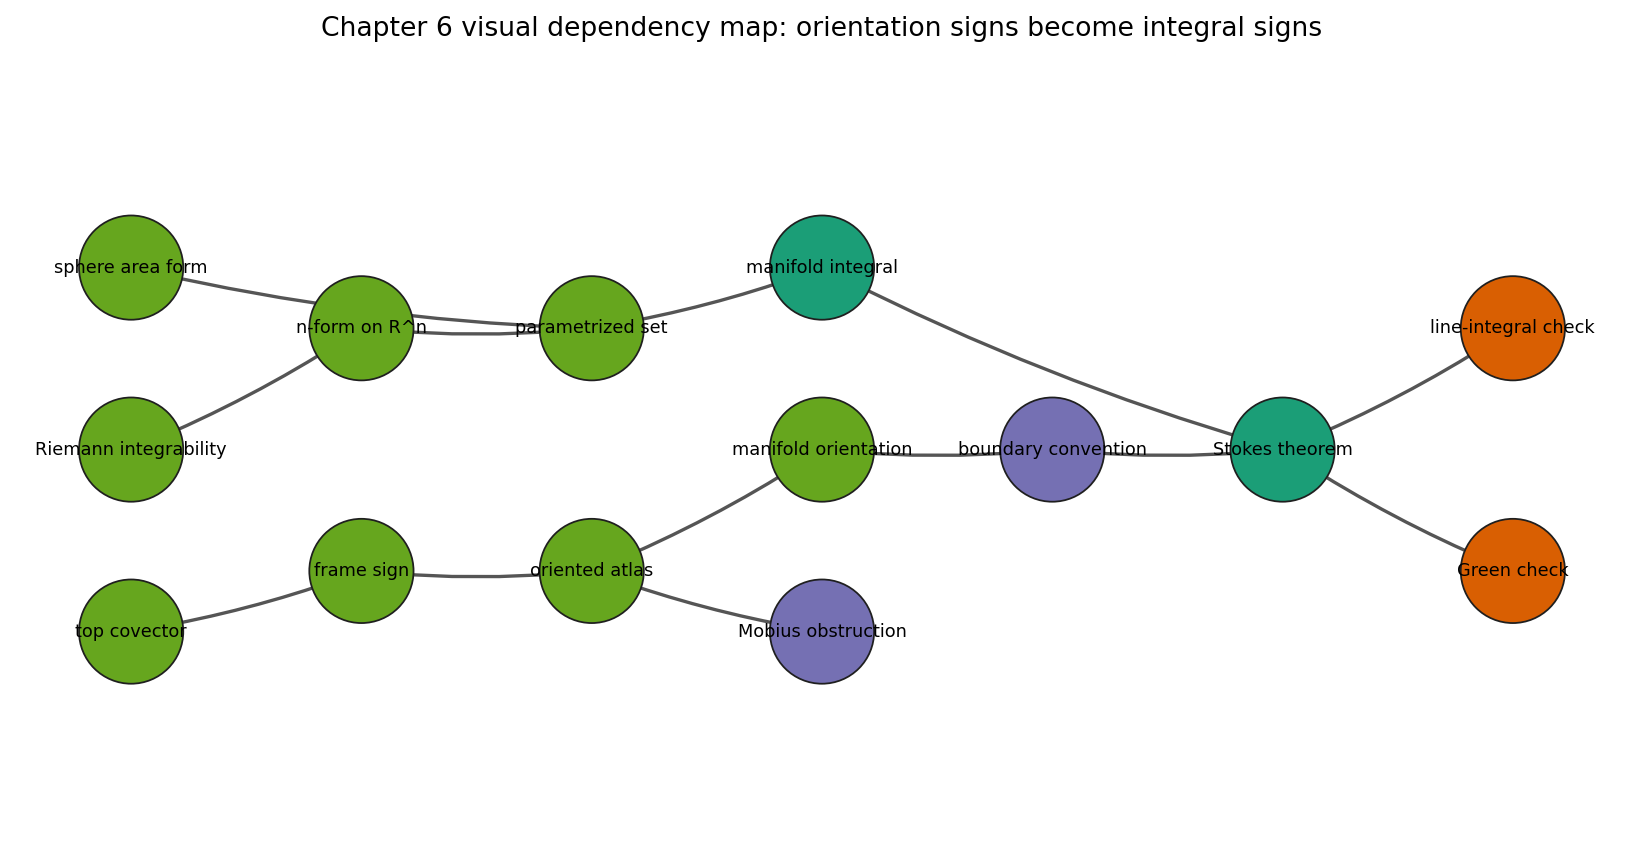

Routing table: `artifacts/chapter-06-integration/tables/ch06-library-routing.csv`

In [2]:
routing_rows = [
    {"concept": "frame orientation", "representation": "2D ordered bases", "library": "SymPy + Matplotlib", "check": "determinant sign equals top-covector sign"},
    {"concept": "oriented atlas obstruction", "representation": "signed cycle for Mobius gluing", "library": "NetworkX + Matplotlib", "check": "cycle sign product is negative"},
    {"concept": "boundary orientation", "representation": "upper half-plane and contraction", "library": "SymPy + Matplotlib", "check": "outward-first determinant is positive"},
    {"concept": "domain of integration", "representation": "Darboux disk grid", "library": "NumPy + Matplotlib", "check": "upper-lower gap decreases"},
    {"concept": "parametrized set", "representation": "ellipse parameter grid", "library": "SymPy + Plotly", "check": "orientation reversal flips integral sign"},
    {"concept": "Stokes specializations", "representation": "Green and line-integral residuals", "library": "NumPy + Matplotlib", "check": "boundary and interior integrals agree"},
    {"concept": "sphere area form", "representation": "spherical surface density", "library": "SymPy + Plotly", "check": "pullback coefficient integrates to 4*pi"},
]
routing_path = keep(save_csv(routing_rows, TABLES / "ch06-library-routing.csv"))

story_edges = [
    ("top covector", "frame sign"),
    ("frame sign", "oriented atlas"),
    ("oriented atlas", "Mobius obstruction"),
    ("oriented atlas", "manifold orientation"),
    ("manifold orientation", "boundary convention"),
    ("boundary convention", "Stokes theorem"),
    ("Riemann integrability", "n-form on R^n"),
    ("n-form on R^n", "parametrized set"),
    ("parametrized set", "manifold integral"),
    ("manifold integral", "Stokes theorem"),
    ("Stokes theorem", "Green check"),
    ("Stokes theorem", "line-integral check"),
    ("sphere area form", "parametrized set"),
]
G_story = nx.DiGraph()
G_story.add_edges_from(story_edges)
node_layers = {
    "top covector": 0,
    "Riemann integrability": 0,
    "sphere area form": 0,
    "frame sign": 1,
    "n-form on R^n": 1,
    "oriented atlas": 2,
    "parametrized set": 2,
    "Mobius obstruction": 3,
    "manifold orientation": 3,
    "manifold integral": 3,
    "boundary convention": 4,
    "Stokes theorem": 5,
    "Green check": 6,
    "line-integral check": 6,
}
pos = {}
for layer in sorted(set(node_layers.values())):
    nodes = [n for n, l in node_layers.items() if l == layer]
    ys = np.linspace(0, 1, len(nodes) + 2)[1:-1]
    for y, node in zip(ys, nodes):
        pos[node] = (layer, y)

fig, ax = plt.subplots(figsize=(13, 6.5))
colors = []
for node in G_story.nodes:
    if "check" in node:
        colors.append("#d95f02")
    elif node in {"Mobius obstruction", "boundary convention"}:
        colors.append("#7570b3")
    elif node in {"Stokes theorem", "manifold integral"}:
        colors.append("#1b9e77")
    else:
        colors.append("#66a61e")
nx.draw_networkx_edges(G_story, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.5, edge_color="#555555", connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(G_story, pos, ax=ax, node_color=colors, node_size=2200, edgecolors="#1f1f1f", linewidths=0.8)
nx.draw_networkx_labels(G_story, pos, ax=ax, font_size=8)
ax.set_title("Chapter 6 visual dependency map: orientation signs become integral signs")
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.05, 1.05)
ax.axis("off")
storyboard_path = keep(save_matplotlib(fig, FIGURES / "ch06-visual-storyboard.png"))
plt.close(fig)

reachable_from_orientation = nx.descendants(G_story, "top covector") | {"top covector"}
storyboard_report = {
    "source_span": "printed pages 236-273; PDF pages 255-292",
    "node_count": G_story.number_of_nodes(),
    "edge_count": G_story.number_of_edges(),
    "checks_reached_from_orientation": sorted(n for n in reachable_from_orientation if "check" in n or n == "Stokes theorem"),
    "routing_rows": len(routing_rows),
}
storyboard_check_path = keep(save_json(storyboard_report, CHECKS / "ch06-visual-storyboard.json"))

show(storyboard_path, width=900)
display(Markdown(f"Routing table: `{rel(routing_path)}`"))

## Orientations as Determinants and Top Covectors

An orientation of a finite-dimensional real vector space is an equivalence class of ordered bases. Computationally, the class of a frame is the sign of the determinant of the matrix that carries a reference frame to the new frame. A top covector such as `dx wedge dy` reads the same sign by evaluating on the ordered frame.

This is the first place where the chapter's later integration sign appears. If the ordered frame is reversed, the determinant changes sign, the top covector changes sign on that frame, and every top-form integral pulled back by that reversal changes sign as well.

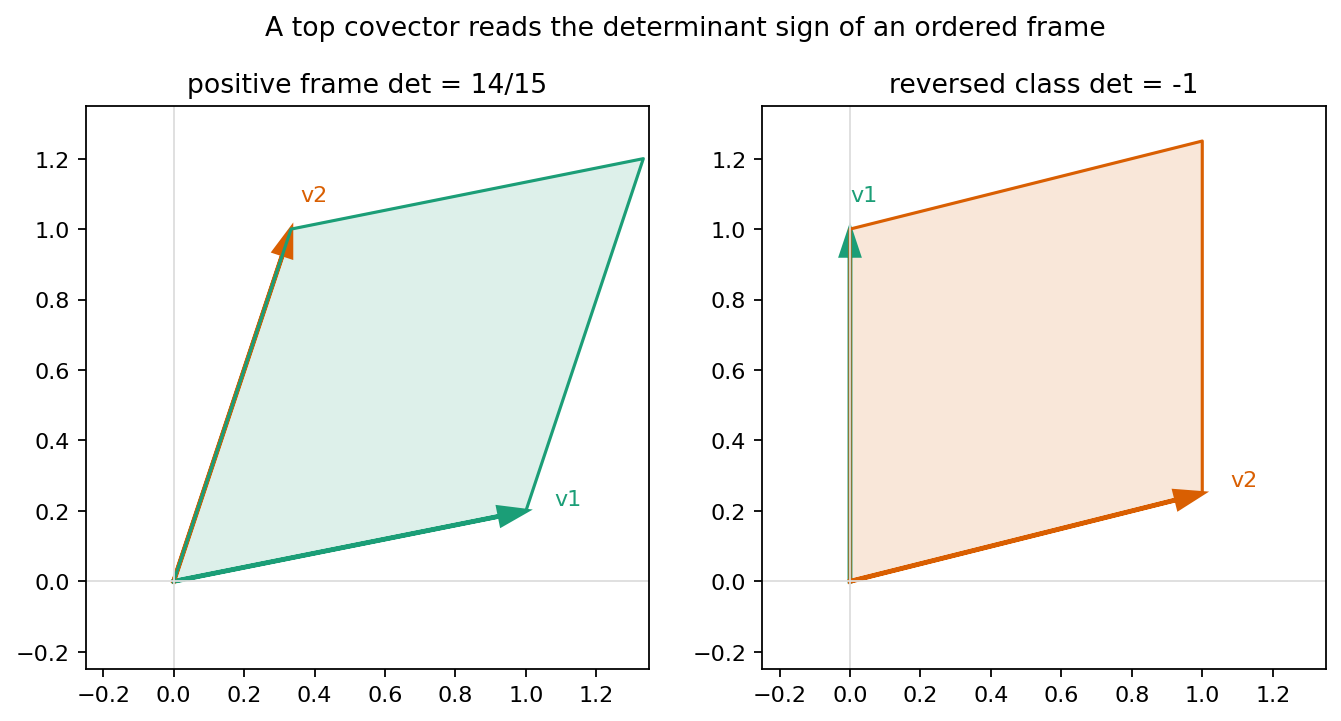

{
  "positive_frame_matrix_columns": [
    [
      "1",
      "1/3"
    ],
    [
      "1/5",
      "1"
    ]
  ],
  "negative_frame_matrix_columns": [
    [
      "0",
      "1"
    ],
    [
      "1",
      "1/4"
    ]
  ],
  "positive_det": "14/15",
  "negative_det": "-1",
  "dx_wedge_dy_on_positive_frame": "14/15",
  "dx_wedge_dy_on_negative_frame": "-1",
  "opposite_orientation_detected": true
}


In [3]:
A_positive = sp.Matrix([[1, sp.Rational(1, 3)], [sp.Rational(1, 5), 1]])
A_negative = sp.Matrix([[0, 1], [1, sp.Rational(1, 4)]])

def det_sign(M):
    det = sp.factor(M.det())
    return det, 1 if det > 0 else -1

positive_det, positive_sign = det_sign(A_positive)
negative_det, negative_sign = det_sign(A_negative)

def draw_frame(ax, M, title, color):
    M_np = np.array(M.tolist(), dtype=float)
    u = M_np[:, 0]
    v = M_np[:, 1]
    poly = np.vstack([[0, 0], u, u + v, v, [0, 0]])
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=0.15)
    ax.plot(poly[:, 0], poly[:, 1], color=color, linewidth=1.4)
    ax.arrow(0, 0, u[0], u[1], head_width=0.05, length_includes_head=True, color="#1b9e77", linewidth=2)
    ax.arrow(0, 0, v[0], v[1], head_width=0.05, length_includes_head=True, color="#d95f02", linewidth=2)
    ax.text(*(u * 1.08), "v1", color="#1b9e77")
    ax.text(*(v * 1.08), "v2", color="#d95f02")
    ax.axhline(0, color="#dddddd", linewidth=0.8)
    ax.axvline(0, color="#dddddd", linewidth=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-0.25, 1.35)
    ax.set_ylim(-0.25, 1.35)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
draw_frame(axes[0], A_positive, f"positive frame det = {positive_det}", "#1b9e77")
draw_frame(axes[1], A_negative, f"reversed class det = {negative_det}", "#d95f02")
fig.suptitle("A top covector reads the determinant sign of an ordered frame")
orientation_frame_path = keep(save_matplotlib(fig, FIGURES / "orientation-frame-sign.png"))
plt.close(fig)

orientation_report = {
    "positive_frame_matrix_columns": [[str(x) for x in row] for row in A_positive.tolist()],
    "negative_frame_matrix_columns": [[str(x) for x in row] for row in A_negative.tolist()],
    "positive_det": str(positive_det),
    "negative_det": str(negative_det),
    "dx_wedge_dy_on_positive_frame": str(positive_det),
    "dx_wedge_dy_on_negative_frame": str(negative_det),
    "opposite_orientation_detected": bool(positive_sign == 1 and negative_sign == -1),
}
orientation_check_path = keep(save_json(orientation_report, CHECKS / "orientation-frame-sign.json"))

show(orientation_frame_path, width=760)
print(json.dumps(orientation_report, indent=2))

## Oriented Atlases and the Mobius Sign Obstruction

An oriented atlas asks every transition map on an overlap to have positive Jacobian determinant. The open Mobius band is the useful failure mode: after one trip around the strip, the gluing map keeps the longitudinal direction and flips the transverse direction. That transition has determinant `-1`, so any attempted continuous choice of local orientation returns with the opposite sign.

The diagram below is not a picture copied from the text. It is a sign model: the two vertical edges of a rectangle are identified with a flip, and the derivative of that gluing map is the whole obstruction.

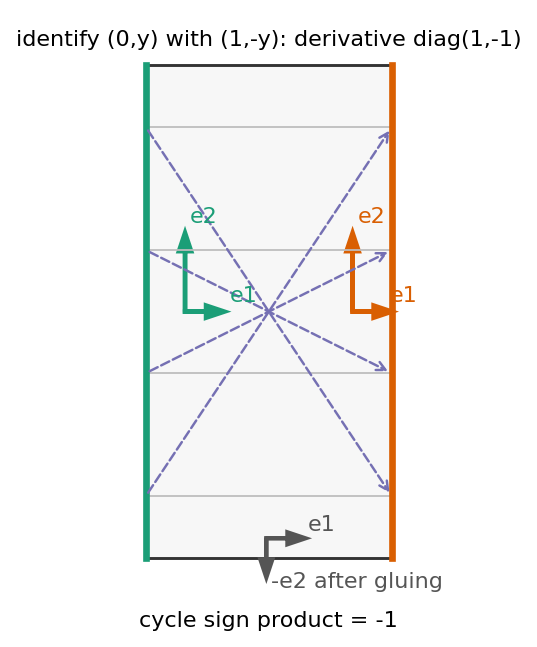

{
  "gluing_derivative": [
    [
      1,
      0
    ],
    [
      0,
      -1
    ]
  ],
  "gluing_determinant": -1,
  "transition_cycle_signs": [
    1,
    1,
    -1
  ],
  "cycle_product": -1,
  "orientable_cycle_test_passed": false,
  "obstruction_detected": true
}


In [4]:
mobius_gluing = sp.Matrix([[1, 0], [0, -1]])
mobius_gluing_det = sp.factor(mobius_gluing.det())
cycle_signs = [1, 1, int(mobius_gluing_det)]
cycle_product = int(np.prod(cycle_signs))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_aspect("equal")
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-1.2, 1.2)
ax.add_patch(plt.Rectangle((0, -1), 1, 2, facecolor="#f7f7f7", edgecolor="#333333", linewidth=1.3))
for y in np.linspace(-0.75, 0.75, 4):
    ax.plot([0, 1], [y, y], color="#bdbdbd", linewidth=0.8)
    ax.annotate("", xy=(1, -y), xytext=(0, y), arrowprops=dict(arrowstyle="->", color="#7570b3", linestyle="--", linewidth=1.1))
ax.plot([0, 0], [-1, 1], color="#1b9e77", linewidth=3)
ax.plot([1, 1], [-1, 1], color="#d95f02", linewidth=3)
ax.arrow(0.16, 0, 0.16, 0, head_width=0.05, length_includes_head=True, color="#1b9e77", linewidth=2)
ax.arrow(0.16, 0, 0, 0.32, head_width=0.05, length_includes_head=True, color="#1b9e77", linewidth=2)
ax.text(0.34, 0.04, "e1", color="#1b9e77")
ax.text(0.18, 0.36, "e2", color="#1b9e77")
ax.arrow(0.84, 0, 0.16, 0, head_width=0.05, length_includes_head=True, color="#d95f02", linewidth=2)
ax.arrow(0.84, 0, 0, 0.32, head_width=0.05, length_includes_head=True, color="#d95f02", linewidth=2)
ax.text(0.99, 0.04, "e1", color="#d95f02")
ax.text(0.86, 0.36, "e2", color="#d95f02")
ax.arrow(0.49, -0.92, 0.16, 0, head_width=0.05, length_includes_head=True, color="#555555", linewidth=1.8)
ax.arrow(0.49, -0.92, 0, -0.16, head_width=0.05, length_includes_head=True, color="#555555", linewidth=1.8)
ax.text(0.66, -0.89, "e1", color="#555555")
ax.text(0.51, -1.12, "-e2 after gluing", color="#555555")
ax.text(0.5, 1.08, "identify (0,y) with (1,-y): derivative diag(1,-1)", ha="center")
ax.text(0.5, -1.28, f"cycle sign product = {cycle_product}", ha="center")
ax.axis("off")
mobius_path = keep(save_matplotlib(fig, FIGURES / "mobius-orientation-obstruction.png"))
plt.close(fig)

mobius_report = {
    "gluing_derivative": [[int(x) for x in row] for row in mobius_gluing.tolist()],
    "gluing_determinant": int(mobius_gluing_det),
    "transition_cycle_signs": cycle_signs,
    "cycle_product": cycle_product,
    "orientable_cycle_test_passed": cycle_product == 1,
    "obstruction_detected": cycle_product == -1,
}
mobius_check_path = keep(save_json(mobius_report, CHECKS / "mobius-orientation-obstruction.json"))

show(mobius_path, width=820)
print(json.dumps(mobius_report, indent=2))

## Boundary Orientation: Outward Vector First

For a manifold with boundary, tangent vectors at a boundary point still live in the full tangent space of the ambient manifold-with-boundary. In `H^2`, both `d/dy` and `-d/dy` are tangent vectors at a boundary point, even though only the upward one is realized by a curve entering the interior.

The boundary orientation convention used here is outward vector first: a boundary tangent `v` is positive exactly when `(outward, v)` is a positive frame for the ambient orientation. For the standard orientation `dx wedge dy` on the upper half-plane, the outward vector is `-d/dy`, and `(-d/dy, d/dx)` has determinant `+1`. The contraction `i_{-d/dy}(dx wedge dy)` is therefore `dx`, which orients the boundary line to the right.

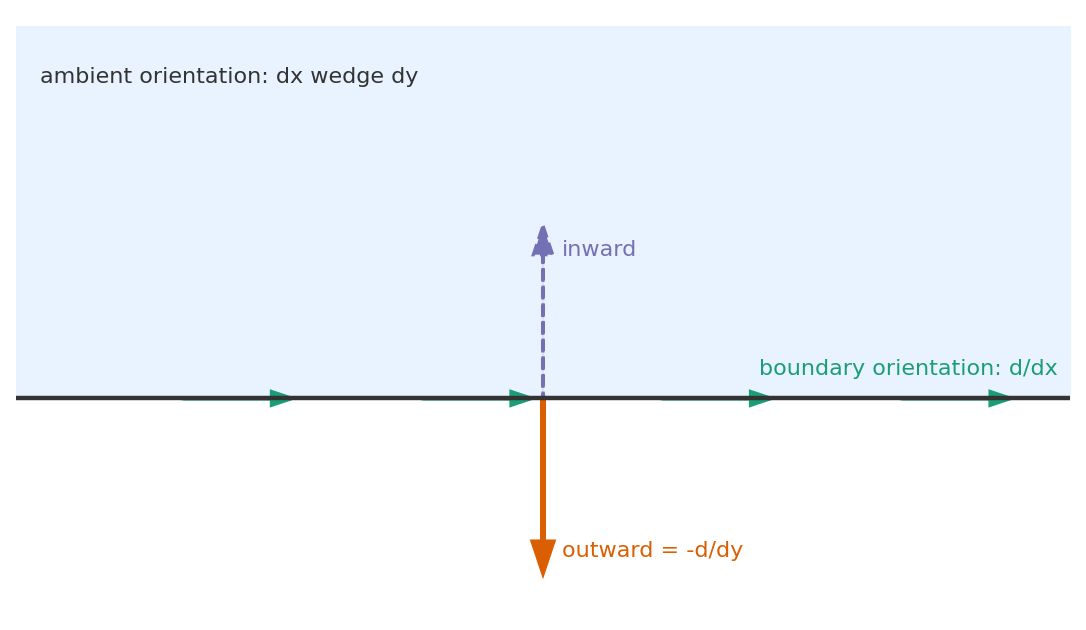

{
  "ambient_orientation": "dx wedge dy",
  "outward_vector": [
    0,
    -1
  ],
  "positive_boundary_tangent": [
    1,
    0
  ],
  "det_outward_then_boundary": 1,
  "det_inward_then_boundary": -1,
  "contraction_i_outward_dx_wedge_dy": "1*dx",
  "boundary_orientation_is_dx": true
}


In [5]:
outward = sp.Matrix([0, -1])
inward = sp.Matrix([0, 1])
boundary_tangent = sp.Matrix([1, 0])
outward_first_det = sp.Matrix.hstack(outward, boundary_tangent).det()
inward_first_det = sp.Matrix.hstack(inward, boundary_tangent).det()
# For X = a d/dx + b d/dy, i_X(dx wedge dy) = a dy - b dx. Here b = -1, so the dx coefficient is 1.
contraction_dx_coeff = -outward[1]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
xx = np.linspace(-2.2, 2.2, 100)
ax.fill_between(xx, 0, 1.55, color="#e6f2ff", alpha=0.9, label="H^2 interior")
ax.plot([-2.2, 2.2], [0, 0], color="#333333", linewidth=2)
for x0 in [-1.5, -0.5, 0.5, 1.5]:
    ax.arrow(x0, 0, 0.45, 0, head_width=0.055, length_includes_head=True, color="#1b9e77", linewidth=1.7)
ax.arrow(0, 0, 0, -0.72, head_width=0.08, length_includes_head=True, color="#d95f02", linewidth=2.4)
ax.arrow(0, 0, 0, 0.72, head_width=0.08, length_includes_head=True, color="#7570b3", linewidth=1.5, linestyle="--")
ax.text(0.08, -0.66, "outward = -d/dy", color="#d95f02")
ax.text(0.08, 0.6, "inward", color="#7570b3")
ax.text(0.9, 0.1, "boundary orientation: d/dx", color="#1b9e77")
ax.text(-2.1, 1.32, "ambient orientation: dx wedge dy", color="#333333")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-0.9, 1.6)
ax.set_aspect("equal")
ax.axis("off")
boundary_path = keep(save_matplotlib(fig, FIGURES / "boundary-outward-first.png"))
plt.close(fig)

boundary_report = {
    "ambient_orientation": "dx wedge dy",
    "outward_vector": [0, -1],
    "positive_boundary_tangent": [1, 0],
    "det_outward_then_boundary": int(outward_first_det),
    "det_inward_then_boundary": int(inward_first_det),
    "contraction_i_outward_dx_wedge_dy": f"{int(contraction_dx_coeff)}*dx",
    "boundary_orientation_is_dx": bool(outward_first_det == 1 and contraction_dx_coeff == 1),
}
boundary_check_path = keep(save_json(boundary_report, CHECKS / "boundary-outward-first.json"))

show(boundary_path, width=760)
print(json.dumps(boundary_report, indent=2))

## Riemann Integrability and Measure-Zero Boundary

Before integrating forms on a manifold, the chapter recalls a Euclidean fact: a bounded continuous function on a bounded region with measure-zero topological boundary is Riemann integrable. The next grid uses the disk indicator only as a diagnostic. Lower sums count grid squares forced to be inside the disk, upper sums count grid squares that touch the disk, and the uncertain area is squeezed near the boundary circle.

This does not prove the theorem, but it makes the role of the boundary visible. The area gap should shrink under refinement because fewer grid squares straddle the boundary.

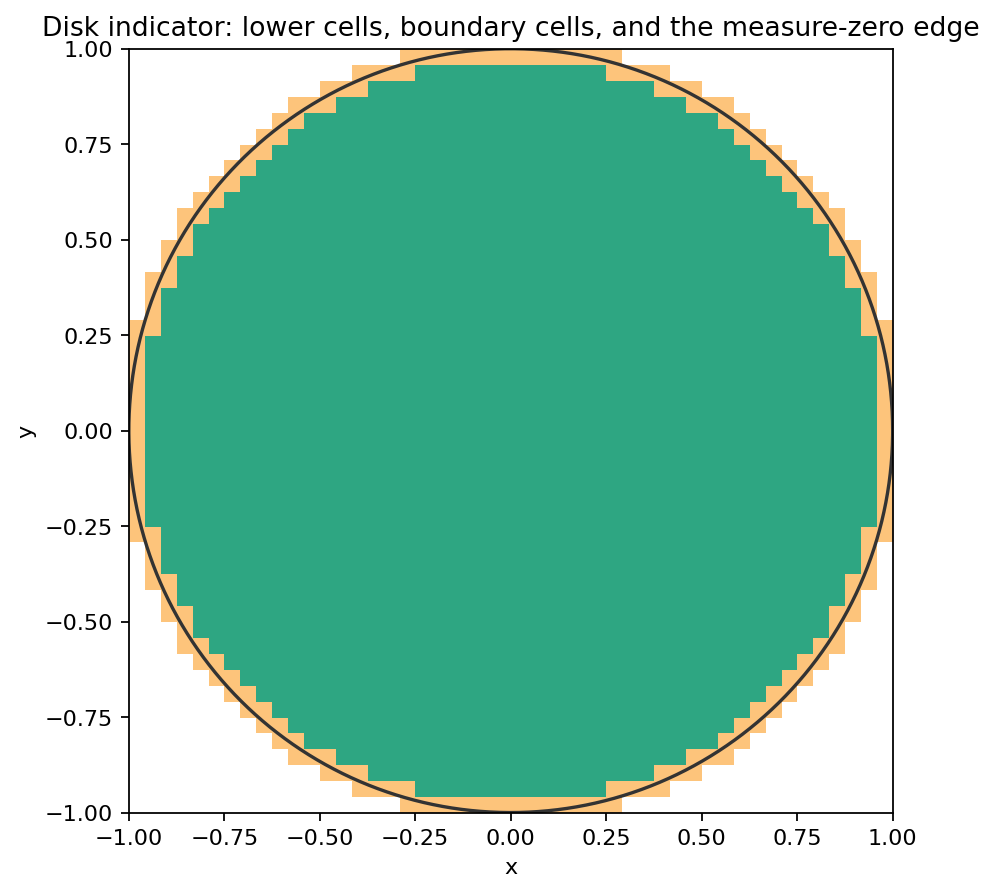

Darboux table: `artifacts/chapter-06-integration/tables/riemann-disk-darboux-bounds.csv`

{
  "refinements": [
    {
      "N": 12,
      "lower_sum": 2.444444444444444,
      "upper_sum": 3.6666666666666665,
      "gap": 1.2222222222222223,
      "pi_error_midpoint": 0.08603709803423776
    },
    {
      "N": 24,
      "lower_sum": 2.722222222222222,
      "upper_sum": 3.3611111111111107,
      "gap": 0.6388888888888888,
      "pi_error_midpoint": 0.09992598692312704
    },
    {
      "N": 48,
      "lower_sum": 2.9444444444444438,
      "upper_sum": 3.270833333333333,
      "gap": 0.3263888888888893,
      "pi_error_midpoint": 0.03395376470090472
    }
  ],
  "gaps_strictly_decrease": true,
  "smallest_gap": 0.3263888888888893,
  "actual_disk_area": 3.141592653589793
}


In [6]:
def disk_darboux_bounds(N):
    h = 2.0 / N
    lower_count = 0
    upper_count = 0
    classes = np.zeros((N, N), dtype=int)
    xs = np.linspace(-1, 1, N + 1)
    ys = np.linspace(-1, 1, N + 1)
    for i in range(N):
        for j in range(N):
            x0, x1 = xs[i], xs[i + 1]
            y0, y1 = ys[j], ys[j + 1]
            corners = np.array([[x0, y0], [x0, y1], [x1, y0], [x1, y1]])
            max_r2 = np.max(np.sum(corners**2, axis=1))
            closest_x = 0 if x0 <= 0 <= x1 else min(abs(x0), abs(x1))
            closest_y = 0 if y0 <= 0 <= y1 else min(abs(y0), abs(y1))
            min_r2 = closest_x**2 + closest_y**2
            if max_r2 <= 1.0:
                lower_count += 1
                upper_count += 1
                classes[j, i] = 2
            elif min_r2 <= 1.0:
                upper_count += 1
                classes[j, i] = 1
    lower = lower_count * h * h
    upper = upper_count * h * h
    return lower, upper, classes

refinements = [12, 24, 48]
riemann_rows = []
class_images = {}
for N in refinements:
    lower, upper, classes = disk_darboux_bounds(N)
    riemann_rows.append({
        "N": N,
        "lower_sum": lower,
        "upper_sum": upper,
        "gap": upper - lower,
        "pi_error_midpoint": abs((lower + upper) / 2 - math.pi),
    })
    class_images[N] = classes
riemann_table_path = keep(save_csv(riemann_rows, TABLES / "riemann-disk-darboux-bounds.csv"))

N_show = 48
fig, ax = plt.subplots(figsize=(6.2, 6.2))
cmap = ListedColormap(["#ffffff", "#fdbf6f", "#1b9e77"])
ax.imshow(class_images[N_show], origin="lower", extent=[-1, 1, -1, 1], cmap=cmap, interpolation="nearest", alpha=0.92)
theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta), color="#333333", linewidth=1.5)
ax.set_aspect("equal")
ax.set_title("Disk indicator: lower cells, boundary cells, and the measure-zero edge")
ax.set_xlabel("x")
ax.set_ylabel("y")
riemann_grid_path = keep(save_matplotlib(fig, FIGURES / "riemann-disk-boundary-grid.png"))
plt.close(fig)

gaps = [row["gap"] for row in riemann_rows]
riemann_report = {
    "refinements": riemann_rows,
    "gaps_strictly_decrease": all(gaps[i + 1] < gaps[i] for i in range(len(gaps) - 1)),
    "smallest_gap": gaps[-1],
    "actual_disk_area": math.pi,
}
riemann_check_path = keep(save_json(riemann_report, CHECKS / "riemann-disk-boundary-grid.json"))

show(riemann_grid_path, width=620)
display(Markdown(f"Darboux table: `{rel(riemann_table_path)}`"))
print(json.dumps(riemann_report, indent=2))

## Integration Under Parametrization and Orientation Reversal

For an `n`-form, the pullback uses the signed Jacobian determinant. This is the main difference between integrating a form and computing unsigned volume by change of variables. The two maps below cover the same ellipse from the unit disk:

- `F_+(u,v) = (a u, b v)` has Jacobian `ab` and preserves orientation.
- `F_-(u,v) = (-a u, b v)` has Jacobian `-ab` and reverses orientation.

The same geometric region therefore gives opposite signed integrals for the form `dx wedge dy`. This is the computational version of the proposition that reversing the orientation of a manifold reverses the sign of a top-form integral.

In [7]:
a_val = 2.0
b_val = 0.75
a_sym, b_sym = sp.symbols("a b", positive=True)
J_plus = sp.Matrix([[a_sym, 0], [0, b_sym]]).det()
J_minus = sp.Matrix([[-a_sym, 0], [0, b_sym]]).det()
ellipse_integral_plus = sp.pi * J_plus
ellipse_integral_minus = sp.pi * J_minus

angles = np.linspace(0, 2 * np.pi, 240)
radii = np.linspace(0.2, 1.0, 5)
fig = make_subplots(rows=1, cols=2, subplot_titles=("orientation preserving", "orientation reversing"))
for col, sign in [(1, 1), (2, -1)]:
    for r in radii:
        x = sign * a_val * r * np.cos(angles)
        y = b_val * r * np.sin(angles)
        fig.add_trace(go.Scatter(x=x, y=y, mode="lines", line=dict(color="#bdbdbd", width=1), showlegend=False), row=1, col=col)
    for angle in np.linspace(0, 2 * np.pi, 12, endpoint=False):
        rr = np.linspace(0, 1, 80)
        x = sign * a_val * rr * np.cos(angle)
        y = b_val * rr * np.sin(angle)
        fig.add_trace(go.Scatter(x=x, y=y, mode="lines", line=dict(color="#d9d9d9", width=1), showlegend=False), row=1, col=col)
    x = sign * a_val * np.cos(angles)
    y = b_val * np.sin(angles)
    fig.add_trace(go.Scatter(x=x, y=y, mode="lines", line=dict(color="#1b9e77" if sign == 1 else "#d95f02", width=3), showlegend=False), row=1, col=col)
fig.update_xaxes(scaleanchor="y", scaleratio=1, range=[-2.25, 2.25])
fig.update_yaxes(range=[-1.2, 1.2])
fig.update_layout(width=900, height=420, title="Same ellipse, opposite signed Jacobians for dx wedge dy", margin=dict(l=20, r=20, t=70, b=20))
ellipse_html_path = keep(save_plotly_standalone(fig, HTML / "parameterized-ellipse-orientation.html"))

ellipse_report = {
    "a": a_val,
    "b": b_val,
    "jacobian_preserving": str(J_plus),
    "jacobian_reversing": str(J_minus),
    "integral_preserving_symbolic": str(ellipse_integral_plus),
    "integral_reversing_symbolic": str(ellipse_integral_minus),
    "integral_preserving_numeric": float(ellipse_integral_plus.subs({a_sym: a_val, b_sym: b_val})),
    "integral_reversing_numeric": float(ellipse_integral_minus.subs({a_sym: a_val, b_sym: b_val})),
    "orientation_reversal_flips_sign": bool(sp.simplify(ellipse_integral_plus + ellipse_integral_minus) == 0),
}
ellipse_check_path = keep(save_json(ellipse_report, CHECKS / "parameterized-ellipse-orientation.json"))

show(ellipse_html_path, width=900, height=460)
print(json.dumps(ellipse_report, indent=2))

{
  "a": 2.0,
  "b": 0.75,
  "jacobian_preserving": "a*b",
  "jacobian_reversing": "-a*b",
  "integral_preserving_symbolic": "pi*a*b",
  "integral_reversing_symbolic": "-pi*a*b",
  "integral_preserving_numeric": 4.71238898038469,
  "integral_reversing_numeric": -4.71238898038469,
  "orientation_reversal_flips_sign": true
}


## Integration on Manifolds: Compact Support, Partitions, and Parametrized Sets

On an oriented `n`-manifold, the basic object to integrate is an `n`-form with compact support. The partition-of-unity definition is excellent for proving that the integral is well defined: split the form into finitely many chart-supported pieces, integrate each pulled-back top form in `R^n`, and add. For calculation, parametrized sets are usually better because the pullback is explicit.

The ellipse cell above is the parametrized-set version in two dimensions. The sphere cell below is the same idea for a two-form on a surface: choose a parameter domain, pull the form back to that domain, and integrate the resulting coefficient.

## Stokes, Green, and the Fundamental Theorem for Line Integrals

Stokes's theorem says that the integral of `d omega` over an oriented manifold with boundary equals the integral of `omega` over the boundary with the boundary orientation. In dimension two, this is Green's theorem. In dimension one, it is the fundamental theorem for line integrals, where the boundary of an oriented interval is the signed pair `endpoint - startpoint`.

The next cell performs both checks numerically. For Green's theorem, use `omega = P dx + Q dy` with `P=-y/2` and `Q=x/2` on an ellipse. Then `d omega = dx wedge dy`, so the area integral should equal the boundary integral. For the line-integral check, integrate a gradient field along a curved path in `R^3` and compare it with the endpoint difference of its potential.

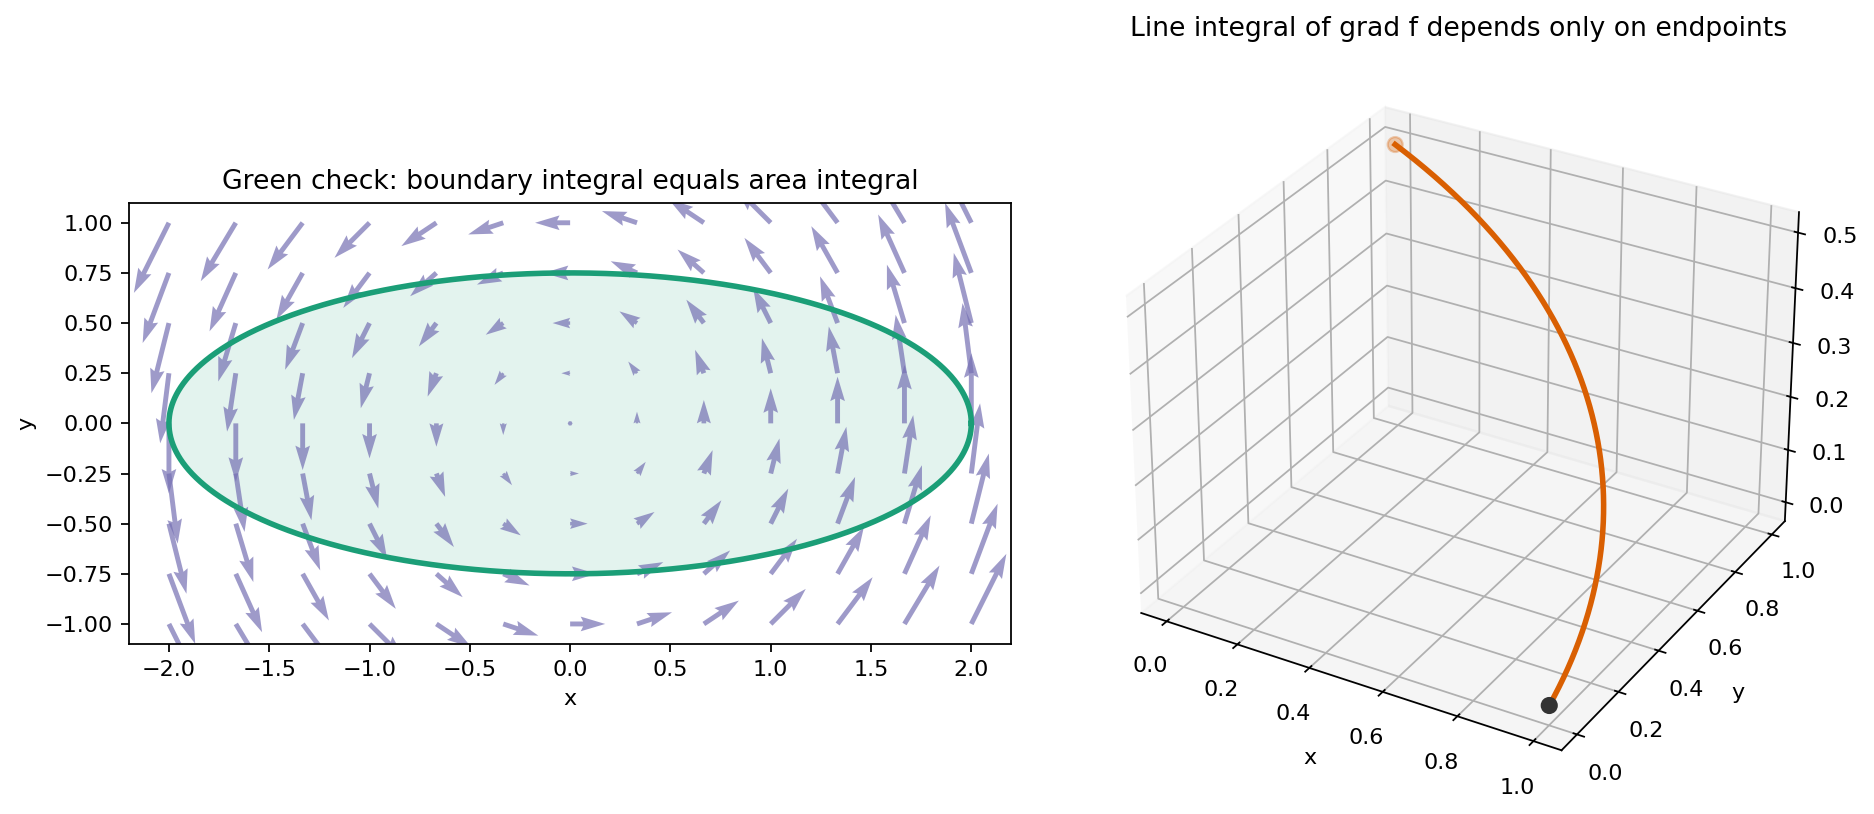

{
  "green_boundary_integral": 4.71238898038469,
  "green_area_integral": 4.71238898038469,
  "green_residual": 0.0,
  "line_integral_grad_f": 0.5000000257020955,
  "endpoint_difference": 0.5,
  "line_residual": 2.5702095451940465e-08,
  "green_passes_tolerance": true,
  "line_passes_tolerance": true
}


In [8]:
trapz = getattr(np, "trapezoid", np.trapz)

# Green check on an ellipse with counterclockwise boundary.
t = np.linspace(0, 2 * np.pi, 5001)
x = a_val * np.cos(t)
y = b_val * np.sin(t)
dx_dt = -a_val * np.sin(t)
dy_dt = b_val * np.cos(t)
P = -0.5 * y
Q = 0.5 * x
green_boundary = float(trapz(P * dx_dt + Q * dy_dt, t))
green_area = math.pi * a_val * b_val
green_residual = abs(green_boundary - green_area)

# Fundamental theorem for line integrals in R^3.
s = np.linspace(0, np.pi / 2, 4001)
rx = np.cos(s)
ry = np.sin(s)
rz = s / np.pi
drx = -np.sin(s)
dry = np.cos(s)
drz = np.full_like(s, 1 / np.pi)
grad_f = np.vstack([2 * rx * ry, rx**2, np.ones_like(s)]).T
rprime = np.vstack([drx, dry, drz]).T
line_integral = float(trapz(np.sum(grad_f * rprime, axis=1), s))
potential_start = float((rx[0] ** 2) * ry[0] + rz[0])
potential_end = float((rx[-1] ** 2) * ry[-1] + rz[-1])
endpoint_difference = potential_end - potential_start
line_residual = abs(line_integral - endpoint_difference)

fig = plt.figure(figsize=(12, 5.2))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x, y, color="#1b9e77", linewidth=2.5)
ax1.fill(x, y, color="#1b9e77", alpha=0.12)
Xq, Yq = np.meshgrid(np.linspace(-2, 2, 13), np.linspace(-1, 1, 9))
U = -0.5 * Yq
V = 0.5 * Xq
ax1.quiver(Xq, Yq, U, V, color="#7570b3", alpha=0.7)
ax1.set_aspect("equal")
ax1.set_title("Green check: boundary integral equals area integral")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(rx, ry, rz, color="#d95f02", linewidth=2.5)
ax2.scatter([rx[0], rx[-1]], [ry[0], ry[-1]], [rz[0], rz[-1]], color=["#333333", "#d95f02"], s=45)
ax2.set_title("Line integral of grad f depends only on endpoints")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
fig.tight_layout()
stokes_path = keep(save_matplotlib(fig, FIGURES / "stokes-green-line-checks.png"))
plt.close(fig)

stokes_report = {
    "green_boundary_integral": green_boundary,
    "green_area_integral": green_area,
    "green_residual": green_residual,
    "line_integral_grad_f": line_integral,
    "endpoint_difference": endpoint_difference,
    "line_residual": line_residual,
    "green_passes_tolerance": green_residual < 2e-6,
    "line_passes_tolerance": line_residual < 2e-6,
}
stokes_check_path = keep(save_json(stokes_report, CHECKS / "stokes-green-line-checks.json"))

show(stokes_path, width=880)
print(json.dumps(stokes_report, indent=2))

## Sphere Area Form

The source span closes with the sphere as a parametrized set. The useful invariant is not the picture of spherical coordinates, but the pullback of the area form. Let

`F(phi, theta) = (sin(phi) cos(theta), sin(phi) sin(theta), cos(phi))`.

For the orientation form induced by the outward radial vector on the unit sphere,

`x dy wedge dz - y dx wedge dz + z dx wedge dy`,

the pullback should be `sin(phi) dphi wedge dtheta`. Integrating that coefficient over `[0, pi] x [0, 2*pi]` gives the surface area `4*pi`. The Plotly surface colors the sphere by this pulled-back density so the poles are visibly low-density and the equator is high-density.

In [9]:
phi, theta_sym = sp.symbols("phi theta", real=True)
x_s = sp.sin(phi) * sp.cos(theta_sym)
y_s = sp.sin(phi) * sp.sin(theta_sym)
z_s = sp.cos(phi)

def wedge_coeff(f, g):
    return sp.diff(f, phi) * sp.diff(g, theta_sym) - sp.diff(f, theta_sym) * sp.diff(g, phi)

pullback_coeff = sp.simplify(
    x_s * wedge_coeff(y_s, z_s)
    - y_s * wedge_coeff(x_s, z_s)
    + z_s * wedge_coeff(x_s, y_s)
)
sphere_area_exact = sp.integrate(sp.integrate(pullback_coeff, (phi, 0, sp.pi)), (theta_sym, 0, 2 * sp.pi))

phi_grid = np.linspace(0, np.pi, 80)
theta_grid = np.linspace(0, 2 * np.pi, 120)
Phi, Theta = np.meshgrid(phi_grid, theta_grid)
X = np.sin(Phi) * np.cos(Theta)
Y = np.sin(Phi) * np.sin(Theta)
Z = np.cos(Phi)
Density = np.sin(Phi)
fig = go.Figure(data=[go.Surface(x=X, y=Y, z=Z, surfacecolor=Density, colorscale="Viridis", colorbar=dict(title="sin(phi)"))])
fig.update_layout(
    title="Sphere area form: pullback density sin(phi)",
    width=820,
    height=640,
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, t=50, b=0),
)
sphere_html_path = keep(save_plotly_standalone(fig, HTML / "sphere-area-form.html"))

sphere_report = {
    "parameterization": "F(phi, theta)=(sin(phi)cos(theta), sin(phi)sin(theta), cos(phi))",
    "pullback_coefficient": str(pullback_coeff),
    "expected_pullback_coefficient": "sin(phi)",
    "sphere_area_exact": str(sp.simplify(sphere_area_exact)),
    "sphere_area_numeric": float(sphere_area_exact.evalf()),
    "pullback_identity_holds": bool(sp.simplify(pullback_coeff - sp.sin(phi)) == 0),
    "area_is_4pi": bool(sp.simplify(sphere_area_exact - 4 * sp.pi) == 0),
}
sphere_check_path = keep(save_json(sphere_report, CHECKS / "sphere-area-form.json"))

show(sphere_html_path, width=820, height=660)
print(json.dumps(sphere_report, indent=2))

{
  "parameterization": "F(phi, theta)=(sin(phi)cos(theta), sin(phi)sin(theta), cos(phi))",
  "pullback_coefficient": "sin(phi)",
  "expected_pullback_coefficient": "sin(phi)",
  "sphere_area_exact": "4*pi",
  "sphere_area_numeric": 12.566370614359172,
  "pullback_identity_holds": true,
  "area_is_4pi": true
}


## Applied Lab

Use the signed examples above as a small laboratory.

1. Change one column of the positive frame so the determinant crosses through zero. Explain why the zero determinant is not a third orientation.
2. Replace the Mobius gluing derivative `diag(1,-1)` by `diag(1,1)`. The sign cycle becomes positive; identify which nonorientability obstruction disappeared.
3. In the boundary diagram, try using the inward vector first. The determinant changes sign, and Stokes's theorem would acquire an unwanted minus sign.
4. Reverse the ellipse boundary parameterization in the Green check. The boundary integral changes sign, but the interior area integral does not, so the boundary orientation hypothesis is visibly violated.
5. In the sphere cell, integrate only over `0 <= phi <= pi/2`. The result should be the area of the upper hemisphere.

## Takeaways

- Orientation is a determinant sign, and a nowhere-zero top form is the smooth global object that records that sign on every tangent space.
- Oriented atlases are a chart-level version of the same data. A negative transition cycle, as in the Mobius model, blocks a global orientation.
- A manifold boundary is intrinsic, not the same as an ambient topological boundary. Smooth invariance of domain is what keeps boundary and interior points from being exchanged by valid charts.
- The boundary orientation is outward vector first. In `H^2`, this makes the boundary orientation `dx` and keeps Stokes's theorem sign-free.
- Integrating an `n`-form is a signed operation: orientation-preserving parametrizations preserve the integral, orientation-reversing parametrizations negate it.
- Green's theorem, the fundamental theorem for line integrals, and the sphere area computation are concrete faces of the same exterior-calculus rule.

In [10]:
# final_sanity
assert_artifacts(generated_artifacts, min_bytes=80)
for path in generated_artifacts:
    assert Path(path).resolve().is_relative_to(ARTIFACT_ROOT.resolve()), rel(path)

assert orientation_report["opposite_orientation_detected"]
assert mobius_report["obstruction_detected"]
assert boundary_report["boundary_orientation_is_dx"]
assert riemann_report["gaps_strictly_decrease"]
assert ellipse_report["orientation_reversal_flips_sign"]
assert stokes_report["green_passes_tolerance"]
assert stokes_report["line_passes_tolerance"]
assert sphere_report["pullback_identity_holds"]
assert sphere_report["area_is_4pi"]

final_sanity_report = {
    "source_span_used": "printed pages 236-273; PDF pages 255-292",
    "artifact_count_before_final_report": len(generated_artifacts),
    "orientation_positive_det": orientation_report["positive_det"],
    "orientation_negative_det": orientation_report["negative_det"],
    "mobius_cycle_product": mobius_report["cycle_product"],
    "boundary_orientation": boundary_report["contraction_i_outward_dx_wedge_dy"],
    "riemann_smallest_gap": riemann_report["smallest_gap"],
    "ellipse_integrals": [ellipse_report["integral_preserving_numeric"], ellipse_report["integral_reversing_numeric"]],
    "green_residual": stokes_report["green_residual"],
    "line_residual": stokes_report["line_residual"],
    "sphere_area_exact": sphere_report["sphere_area_exact"],
    "all_checks_passed": True,
}
final_sanity_path = keep(save_json(final_sanity_report, CHECKS / "final_sanity.json"))
assert_artifacts([final_sanity_path], min_bytes=80)

display(Markdown(f"`final_sanity` passed with {len(generated_artifacts)} generated artifacts. Summary: `{rel(final_sanity_path)}`"))
print(json.dumps(final_sanity_report, indent=2))

`final_sanity` passed with 19 generated artifacts. Summary: `artifacts/chapter-06-integration/checks/final_sanity.json`

{
  "source_span_used": "printed pages 236-273; PDF pages 255-292",
  "artifact_count_before_final_report": 18,
  "orientation_positive_det": "14/15",
  "orientation_negative_det": "-1",
  "mobius_cycle_product": -1,
  "boundary_orientation": "1*dx",
  "riemann_smallest_gap": 0.3263888888888893,
  "ellipse_integrals": [
    4.71238898038469,
    -4.71238898038469
  ],
  "green_residual": 0.0,
  "line_residual": 2.5702095451940465e-08,
  "sphere_area_exact": "4*pi",
  "all_checks_passed": true
}
